# VR Emotion Study - Data Exploration

This notebook loads `weights.csv` files from one recording session and checks whether the collected XR tracking data is usable for analysis or model training.

Expected folder shape:

```text
VideoRecordings/
  20260521-1048/
    Anger/
      weights.csv
    Disgust/
      weights.csv
```


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

# Change this if you analyze a different copied session.
SESSION_ROOT = Path(r"C:\Users\alime\multimodal-vr-emotion-study\multimodal-vr-emotion-study-main\VideoRecordings\20260521-1412")

print(SESSION_ROOT)
print("Exists:", SESSION_ROOT.exists())


C:\Users\alime\multimodal-vr-emotion-study\multimodal-vr-emotion-study-main\VideoRecordings\20260521-1412
Exists: True


## Load All Emotion CSV Files

Each emotion folder should contain one `weights.csv`. We load every available file and add `SourceEmotion` and `SourceFile` columns so we can trace every row back to its folder.


In [2]:
csv_files = sorted(SESSION_ROOT.glob("*/weights.csv"))
print(f"Found {len(csv_files)} weights.csv files")

frames = []
for csv_file in csv_files:
    emotion = csv_file.parent.name
    frame = pd.read_csv(csv_file)
    frame["SourceEmotion"] = emotion
    frame["SourceFile"] = str(csv_file)
    frames.append(frame)

if not frames:
    raise FileNotFoundError(f"No weights.csv files found under {SESSION_ROOT}")

df = pd.concat(frames, ignore_index=True)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")
df.head()


Found 7 weights.csv files
Total rows: 3,041
Total columns: 96


,Timestamp,RealtimeSeconds,Emotion,HeadTracked,HeadX,HeadY,HeadZ,LeftHandTracked,LeftHandX,LeftHandY,LeftHandZ,RightHandTracked,RightHandX,RightHandY,RightHandZ,LeftControllerTracked,LeftControllerX,LeftControllerY,LeftControllerZ,RightControllerTracked,RightControllerX,RightControllerY,RightControllerZ,FaceValid,BrowLowererL,BrowLowererR,CheekPuffL,CheekPuffR,CheekRaiserL,CheekRaiserR,CheekSuckL,CheekSuckR,ChinRaiserB,ChinRaiserT,DimplerL,DimplerR,EyesClosedL,EyesClosedR,EyesLookDownL,EyesLookDownR,EyesLookLeftL,EyesLookLeftR,EyesLookRightL,EyesLookRightR,EyesLookUpL,EyesLookUpR,InnerBrowRaiserL,InnerBrowRaiserR,JawDrop,JawSidewaysLeft,JawSidewaysRight,JawThrust,LidTightenerL,LidTightenerR,LipCornerDepressorL,LipCornerDepressorR,LipCornerPullerL,LipCornerPullerR,LipFunnelerLB,LipFunnelerLT,LipFunnelerRB,LipFunnelerRT,LipPressorL,LipPressorR,LipPuckerL,LipPuckerR,LipStretcherL,LipStretcherR,LipSuckLB,LipSuckLT,LipSuckRB,LipSuckRT,LipTightenerL,LipTightenerR,LipsToward,LowerLipDepressorL,LowerLipDepressorR,MouthLeft,MouthRight,NoseWrinklerL,NoseWrinklerR,OuterBrowRaiserL,OuterBrowRaiserR,UpperLidRaiserL,UpperLidRaiserR,UpperLipRaiserL,UpperLipRaiserR,TongueTipInterdental,TongueTipAlveolar,TongueFrontDorsalPalate,TongueMidDorsalPalate,TongueBackDorsalVelar,TongueOut,TongueRetreat,SourceEmotion,SourceFile
0,154.388107,154.981644,Anger,1,0.284359,1.187762,0.140243,1,0.534258,0.700502,0.265179,1,0.534676,0.982172,-0.094737,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...
1,154.499283,155.093567,Anger,1,0.279327,1.188607,0.141463,1,0.535303,0.697277,0.264443,1,0.479766,0.919551,-0.064425,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...
2,154.610260,155.203735,Anger,1,0.273148,1.188451,0.143721,1,0.536232,0.696555,0.264745,1,0.434309,0.886160,-0.040248,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...
3,154.721481,155.315186,Anger,1,0.266789,1.188459,0.145139,1,0.536752,0.697306,0.264574,1,0.422334,0.851883,-0.032029,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...
4,154.832565,155.427277,Anger,1,0.260671,1.188296,0.143176,1,0.538076,0.696228,0.264664,1,0.425485,0.830012,-0.032174,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...


## Basic Trust Checks

These checks show whether each emotion file has rows, whether timestamps move forward, and whether tracking was valid during recording.


In [3]:
tracking_cols = [
    "HeadTracked",
    "LeftHandTracked",
    "RightHandTracked",
    "LeftControllerTracked",
    "RightControllerTracked",
]

summary_rows = []
for emotion, group in df.groupby("SourceEmotion", sort=True):
    duration = group["Timestamp"].iloc[-1] - group["Timestamp"].iloc[0]
    row = {
        "Emotion": emotion,
        "Rows": len(group),
        "DurationSeconds": round(duration, 2),
    }
    for col in tracking_cols:
        row[f"{col}Rate"] = group[col].mean()
    if "FaceValid" in group:
        row["FaceValidRate"] = group["FaceValid"].mean()
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary


,Emotion,Rows,DurationSeconds,HeadTrackedRate,LeftHandTrackedRate,RightHandTrackedRate,LeftControllerTrackedRate,RightControllerTrackedRate,FaceValidRate
0,Anger,346,38.26,1.0,0.99422,0.991329,0.0,0.0,0.0
1,Disgust,435,48.11,1.0,1.00000,0.944828,0.0,0.0,0.0
2,Fear,299,33.08,1.0,1.00000,1.000000,0.0,0.0,0.0
3,Happiness,981,108.85,1.0,1.00000,1.000000,0.0,0.0,0.0
4,Neutral,236,26.00,1.0,1.00000,1.000000,0.0,0.0,0.0
5,Sadness,609,67.54,1.0,1.00000,0.996716,0.0,0.0,0.0
6,Surprise,135,14.88,1.0,1.00000,0.659259,0.0,0.0,0.0


Interpretation:

- Tracking rates near `1.0` mean the signal was available for most or all rows.
- `FaceValidRate = 0.0` is expected on Meta Quest 3.
- Duration should roughly match how long the emotion video was playing.


## Movement Features

We calculate frame-to-frame distance and speed for head, hands, and controllers. These are usually more useful for training than raw position alone because they describe movement behavior.


In [4]:
signal_prefixes = ["Head", "LeftHand", "RightHand", "LeftController", "RightController"]

def add_motion_features(group):
    group = group.sort_values("Timestamp").copy()
    dt = group["Timestamp"].diff()
    group["DeltaTime"] = dt

    for prefix in signal_prefixes:
        x, y, z = f"{prefix}X", f"{prefix}Y", f"{prefix}Z"
        if not {x, y, z}.issubset(group.columns):
            continue

        distance = np.sqrt(
            group[x].diff() ** 2 +
            group[y].diff() ** 2 +
            group[z].diff() ** 2
        )
        group[f"{prefix}Distance"] = distance
        group[f"{prefix}Speed"] = distance / dt.replace(0, np.nan)

    return group

# pandas 3+ groupby.apply() drops grouping columns; loop keeps SourceEmotion
motion_parts = []
for emotion, group in df.groupby("SourceEmotion", sort=True):
    part = add_motion_features(group)
    part["SourceEmotion"] = emotion
    motion_parts.append(part)

motion_df = pd.concat(motion_parts, ignore_index=True)
motion_df.head()


,Timestamp,RealtimeSeconds,Emotion,HeadTracked,HeadX,HeadY,HeadZ,LeftHandTracked,LeftHandX,LeftHandY,LeftHandZ,RightHandTracked,RightHandX,RightHandY,RightHandZ,LeftControllerTracked,LeftControllerX,LeftControllerY,LeftControllerZ,RightControllerTracked,RightControllerX,RightControllerY,RightControllerZ,FaceValid,BrowLowererL,BrowLowererR,CheekPuffL,CheekPuffR,CheekRaiserL,CheekRaiserR,CheekSuckL,CheekSuckR,ChinRaiserB,ChinRaiserT,DimplerL,DimplerR,EyesClosedL,EyesClosedR,EyesLookDownL,EyesLookDownR,EyesLookLeftL,EyesLookLeftR,EyesLookRightL,EyesLookRightR,EyesLookUpL,EyesLookUpR,InnerBrowRaiserL,InnerBrowRaiserR,JawDrop,JawSidewaysLeft,JawSidewaysRight,JawThrust,LidTightenerL,LidTightenerR,LipCornerDepressorL,LipCornerDepressorR,LipCornerPullerL,LipCornerPullerR,LipFunnelerLB,LipFunnelerLT,LipFunnelerRB,LipFunnelerRT,LipPressorL,LipPressorR,LipPuckerL,LipPuckerR,LipStretcherL,LipStretcherR,LipSuckLB,LipSuckLT,LipSuckRB,LipSuckRT,LipTightenerL,LipTightenerR,LipsToward,LowerLipDepressorL,LowerLipDepressorR,MouthLeft,MouthRight,NoseWrinklerL,NoseWrinklerR,OuterBrowRaiserL,OuterBrowRaiserR,UpperLidRaiserL,UpperLidRaiserR,UpperLipRaiserL,UpperLipRaiserR,TongueTipInterdental,TongueTipAlveolar,TongueFrontDorsalPalate,TongueMidDorsalPalate,TongueBackDorsalVelar,TongueOut,TongueRetreat,SourceEmotion,SourceFile,DeltaTime,HeadDistance,HeadSpeed,LeftHandDistance,LeftHandSpeed,RightHandDistance,RightHandSpeed,LeftControllerDistance,LeftControllerSpeed,RightControllerDistance,RightControllerSpeed
0,154.388107,154.981644,Anger,1,0.284359,1.187762,0.140243,1,0.534258,0.700502,0.265179,1,0.534676,0.982172,-0.094737,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,154.499283,155.093567,Anger,1,0.279327,1.188607,0.141463,1,0.535303,0.697277,0.264443,1,0.479766,0.919551,-0.064425,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...,0.111176,0.005246,0.047186,0.003469,0.031204,0.088630,0.797205,0.0,0.0,0.0,0.0
2,154.610260,155.203735,Anger,1,0.273148,1.188451,0.143721,1,0.536232,0.696555,0.264745,1,0.434309,0.886160,-0.040248,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...,0.110977,0.006580,0.059293,0.001214,0.010943,0.061367,0.552967,0.0,0.0,0.0,0.0
3,154.721481,155.315186,Anger,1,0.266789,1.188459,0.145139,1,0.536752,0.697306,0.264574,1,0.422334,0.851883,-0.032029,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...,0.111221,0.006516,0.058583,0.000928,0.008347,0.037227,0.334712,0.0,0.0,0.0,0.0
4,154.832565,155.427277,Anger,1,0.260671,1.188296,0.143176,1,0.538076,0.696228,0.264664,1,0.425485,0.830012,-0.032174,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Anger,C:\Users\alime\multimodal-vr-emotion-study\mul...,0.111084,0.006427,0.057855,0.001709,0.015387,0.022098,0.198926,0.0,0.0,0.0,0.0


## Feature Summary By Emotion

This table gives compact trainable features for each emotion recording.


In [5]:
feature_rows = []
for emotion, group in motion_df.groupby("SourceEmotion", sort=True):
    row = {
        "Emotion": emotion,
        "Rows": len(group),
        "DurationSeconds": group["Timestamp"].iloc[-1] - group["Timestamp"].iloc[0],
    }

    for prefix in signal_prefixes:
        speed_col = f"{prefix}Speed"
        if speed_col in group:
            speeds = group[speed_col].replace([np.inf, -np.inf], np.nan).dropna()
            row[f"{prefix}MeanSpeed"] = speeds.mean()
            row[f"{prefix}MaxSpeed"] = speeds.max()
            row[f"{prefix}SpeedStd"] = speeds.std()

    feature_rows.append(row)

features = pd.DataFrame(feature_rows)
features


,Emotion,Rows,DurationSeconds,HeadMeanSpeed,HeadMaxSpeed,HeadSpeedStd,LeftHandMeanSpeed,LeftHandMaxSpeed,LeftHandSpeedStd,RightHandMeanSpeed,RightHandMaxSpeed,RightHandSpeedStd,LeftControllerMeanSpeed,LeftControllerMaxSpeed,LeftControllerSpeedStd,RightControllerMeanSpeed,RightControllerMaxSpeed,RightControllerSpeedStd
0,Anger,346,38.264252,0.016908,0.210991,0.028850,0.080011,8.345346,0.639101,0.100884,9.611216,0.728298,0.0,0.0,0.0,0.0,0.0,0.0
1,Disgust,435,48.110900,0.021327,0.157226,0.030855,0.007666,0.089944,0.011260,0.062111,9.263623,0.628863,0.0,0.0,0.0,0.0,0.0,0.0
2,Fear,299,33.083336,0.008438,0.106948,0.017995,0.008249,0.059227,0.007339,0.018967,0.993459,0.089685,0.0,0.0,0.0,0.0,0.0,0.0
3,Happiness,981,108.847183,0.006485,0.129347,0.012821,0.010467,0.891300,0.044180,0.010403,0.762752,0.047467,0.0,0.0,0.0,0.0,0.0,0.0
4,Neutral,236,26.000023,0.012042,0.147849,0.017288,0.012799,0.070727,0.011454,0.020494,0.711885,0.076036,0.0,0.0,0.0,0.0,0.0,0.0
5,Sadness,609,67.541777,0.007903,0.233476,0.023786,0.009287,0.221166,0.015579,0.048391,9.377001,0.538714,0.0,0.0,0.0,0.0,0.0,0.0
6,Surprise,135,14.875672,0.024695,0.252663,0.036632,0.012845,0.087765,0.017207,0.221496,9.712845,1.159190,0.0,0.0,0.0,0.0,0.0,0.0


## Plot Head Position Over Time

This plot helps confirm that the headset position changes naturally during each emotion recording.


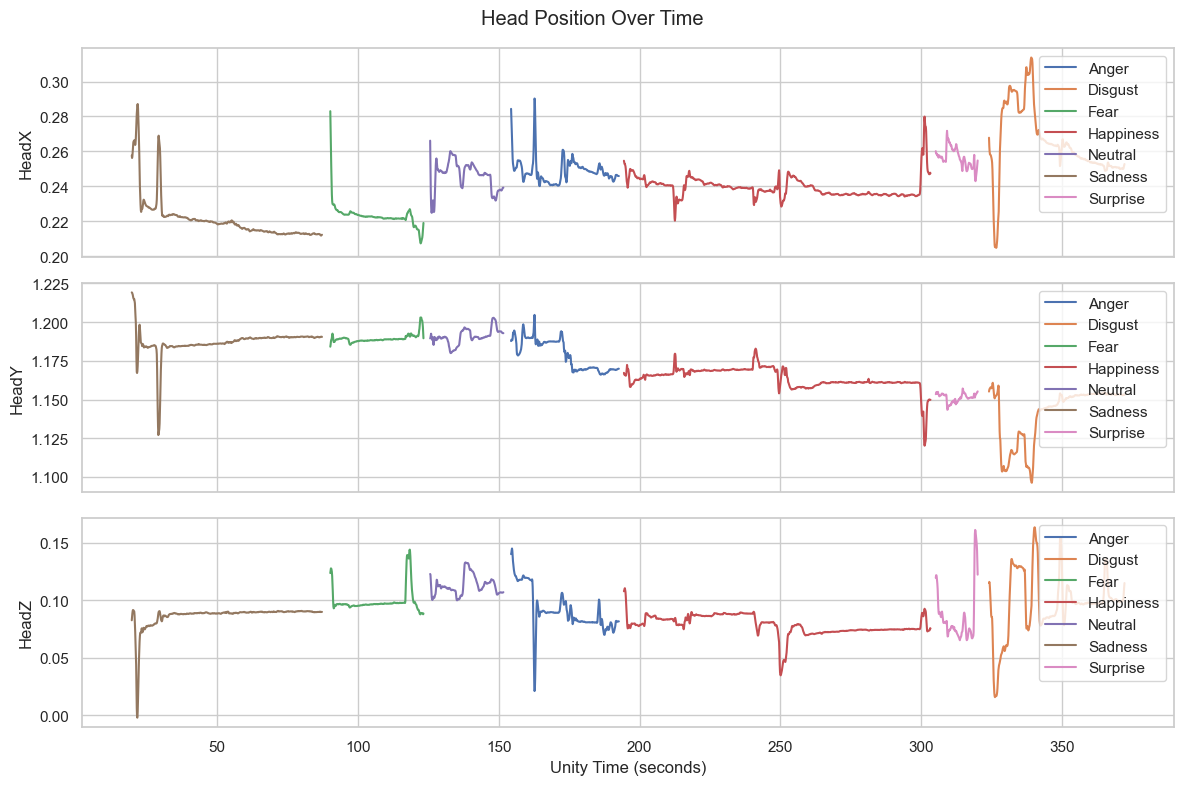

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for axis_name, ax in zip(["HeadX", "HeadY", "HeadZ"], axes):
    sns.lineplot(data=motion_df, x="Timestamp", y=axis_name, hue="SourceEmotion", ax=ax)
    ax.set_ylabel(axis_name)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Unity Time (seconds)")
fig.suptitle("Head Position Over Time")
plt.tight_layout()
plt.show()


## Plot Movement Speed By Emotion

This compares how much movement happened during each emotion video.


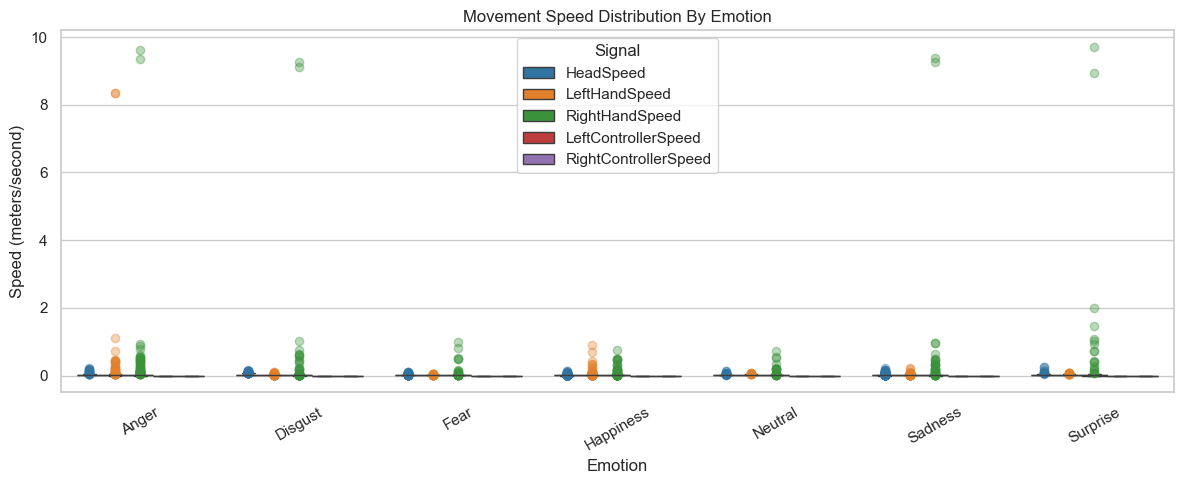

In [7]:
speed_long = motion_df.melt(
    id_vars=["SourceEmotion", "Timestamp"],
    value_vars=[f"{prefix}Speed" for prefix in signal_prefixes if f"{prefix}Speed" in motion_df.columns],
    var_name="Signal",
    value_name="Speed",
)

speed_long = speed_long.replace([np.inf, -np.inf], np.nan).dropna(subset=["Speed"])

signal_palette = {
    "HeadSpeed": "#1f77b4",
    "LeftHandSpeed": "#ff7f0e",
    "RightHandSpeed": "#2ca02c",
    "LeftControllerSpeed": "#d62728",
    "RightControllerSpeed": "#9467bd",
}

hue_order = [signal for signal in signal_palette if signal in speed_long["Signal"].unique()]

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=speed_long,
    x="SourceEmotion",
    y="Speed",
    hue="Signal",
    hue_order=hue_order,
    palette=signal_palette,
)

# palette colors the boxes; matplotlib still draws outliers in black
for i, flier in enumerate(ax.lines[5::6]):
    color = ax.patches[i].get_facecolor()
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
    flier.set_color(color)
    flier.set_alpha(0.35)

plt.title("Movement Speed Distribution By Emotion")
plt.xlabel("Emotion")
plt.ylabel("Speed (meters/second)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Export Feature Table

This creates a compact CSV that can be used as a first machine-learning input table: one row per emotion recording.


In [ ]:
OUTPUT_DIR = SESSION_ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

features_path = OUTPUT_DIR / "emotion_motion_features.csv"
features.to_csv(features_path, index=False)

print(features_path)
features
